# GENCYS 2.0 - Exercise No. 6

# Grover's Algorithm: Searching Faster with Qubits

### Qiskit 2.5.2 - Google Colab Notebook

## The problem: finding one item in an unsorted pile

Imagine you have a bag of **N** numbered balls, all mixed up randomly — no order, no sorting. Someone tells you "ball #57 is special," and asks you to find it just by drawing balls out and checking, one at a time.

**Classically**, there's no shortcut. In the worst case, you check every single ball before you find it. On average you'll need to check about **N/2** balls, and in the worst case, all **N**. Computer scientists write this as **O(N)** — the effort grows in direct proportion to how many balls are in the bag.

**Grover's algorithm** is a quantum method that finds the special ball in roughly **√N** steps instead of N. For a bag of 1,000,000 balls, classical search needs up to 1,000,000 checks — Grover's algorithm needs only about **1,000**. That gap gets more dramatic the bigger the pile gets.

This notebook will:
1. Prove the classical vs quantum gap with real numbers and a chart
2. Build and run an actual Grover circuit on a small example
3. Show you, interactively, exactly how the "probability of finding the right answer" builds up round by round
4. Give you a hands-on exercise to build your own search

## Step 0: Setup

In [1]:
!pip install -q "qiskit==2.5.2" "qiskit-aer~=0.17" pandas matplotlib ipywidgets pylatexenc
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 57.3 MB/s eta 0:00:00
Setup complete.


In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

simulator = AerSimulator()
print("Imports done.")

Imports done.


---
## Part 1: How much faster, really?

Classical search: worst case = N checks.
Grover's algorithm: needs about `(π/4) × √N` rounds — each "round" is one pass through the circuit, not one item checked, but it plays the same role.

Let's compute both for a range of pile sizes and see the gap for ourselves.

In [3]:
pile_sizes = [4, 16, 64, 256, 1_024, 4_096, 16_384, 65_536, 262_144, 1_048_576]

classical_steps = pile_sizes
quantum_steps = [round((math.pi / 4) * math.sqrt(n)) for n in pile_sizes]

df_compare = pd.DataFrame({
    "Pile size (N)": pile_sizes,
    "Classical worst case": classical_steps,
    "Grover's algorithm (~rounds)": quantum_steps,
    "Speedup factor": [round(c / q, 1) for c, q in zip(classical_steps, quantum_steps)],
})
df_compare

,Pile size (N),Classical worst case,Grover's algorithm (~rounds),Speedup factor
0,4,4,2,2.0
1,16,16,3,5.3
2,64,64,6,10.7
3,256,256,13,19.7
4,1024,1024,25,41.0
5,4096,4096,50,81.9
6,16384,16384,101,162.2
7,65536,65536,201,326.0
8,262144,262144,402,652.1
9,1048576,1048576,804,1304.2


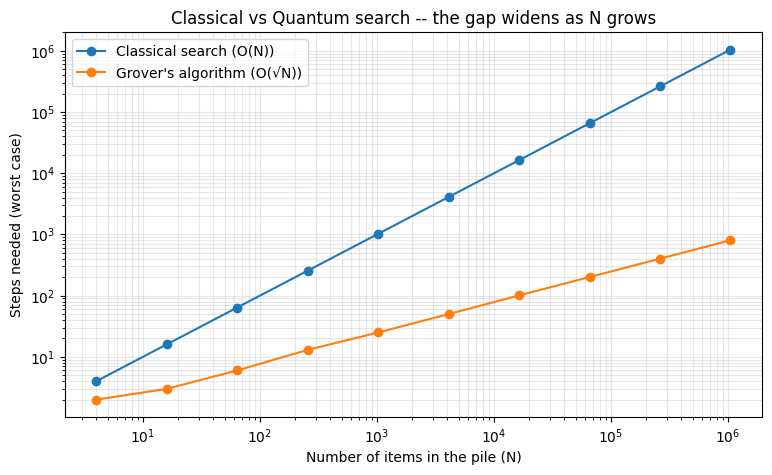

In [4]:
plt.figure(figsize=(9, 5))
plt.plot(pile_sizes, classical_steps, marker='o', label="Classical search (O(N))")
plt.plot(pile_sizes, quantum_steps, marker='o', label="Grover's algorithm (O(√N))")
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Number of items in the pile (N)")
plt.ylabel("Steps needed (worst case)")
plt.title("Classical vs Quantum search -- the gap widens as N grows")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.show()

Notice: at N=4 the two are almost the same. By N=1,000,000, classical search needs up to a million checks, and Grover's algorithm needs only about 785. **The bigger the haystack, the bigger Grover's advantage.**

---
## Part 2: How does it actually work? (No heavy math, just intuition)

Grover's algorithm doesn't "peek" at the answer early — that's not allowed. Instead, it does something clever with **amplitudes** (think of these as the "volume" or "weight" each possible answer carries in the superposition).

Here's the two-step dance, repeated over and over:

1. **The Oracle** — a step that recognizes the correct answer and flips its sign (its amplitude goes negative), while leaving every other answer completely untouched. Think of this like a spotlight that quietly marks the right ball, without revealing which one it marked.
2. **The Diffuser** — a step that takes the *average* amplitude across all the answers, and reflects every single amplitude around that average. Because the correct answer was just flipped negative, this reflection step boosts it upward far more than it boosts anything else.

Repeat that pair of steps roughly √N times, and the correct answer's amplitude grows tall while everything else shrinks — so when you finally measure, you land on the right answer with very high probability.

**Important:** if you keep repeating past the optimal point, the probability actually starts going back *down* again (it overshoots, like over-tightening a guitar string). We'll see this rise-and-fall pattern for ourselves in Part 4.

---
## Part 3: Let's actually run one

We'll search a tiny pile of just **4 items** (using 2 qubits — 2 qubits can represent 4 different states: `00`, `01`, `10`, `11`). Let's say the "special ball" is `11`.

First, the two building blocks: the **oracle** (marks the target) and the **diffuser** (boosts it). You don't need to understand every gate here yet — just notice the shape: oracle, then diffuser, repeated.

In [5]:
def oracle_2qubit(marked_state):
    """Flips the sign of the marked_state (e.g. '11') and leaves everything else alone."""
    qc = QuantumCircuit(2)
    if marked_state[0] == '0':
        qc.x(0)
    if marked_state[1] == '0':
        qc.x(1)
    qc.h(1)
    qc.cx(0, 1)
    qc.h(1)
    if marked_state[0] == '0':
        qc.x(0)
    if marked_state[1] == '0':
        qc.x(1)
    return qc

def diffuser_2qubit():
    """Reflects every amplitude around the average -- boosts whatever was just marked."""
    qc = QuantumCircuit(2)
    qc.h([0, 1])
    qc.x([0, 1])
    qc.h(1)
    qc.cx(0, 1)
    qc.h(1)
    qc.x([0, 1])
    qc.h([0, 1])
    return qc

print("oracle_2qubit and diffuser_2qubit defined")

oracle_2qubit and diffuser_2qubit defined


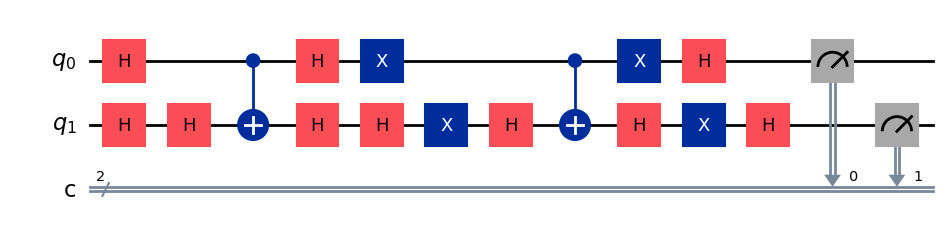

In [6]:
target = "11"

qc = QuantumCircuit(2, 2)
qc.h([0, 1])                          # start in an equal mix of all 4 answers
qc.compose(oracle_2qubit(target), inplace=True)
qc.compose(diffuser_2qubit(), inplace=True)
qc.measure([0, 1], [0, 1])

qc.draw('mpl')

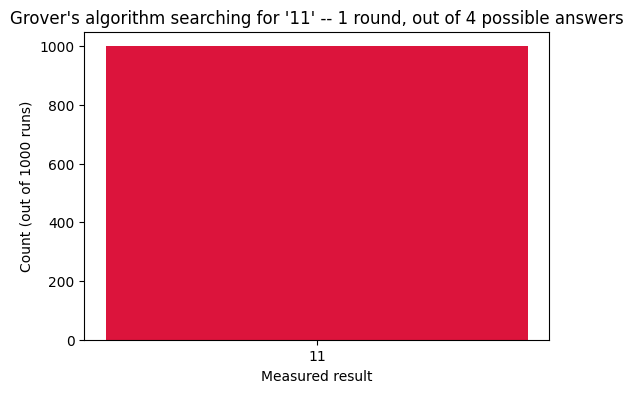

{'11': 1000}

Out of 1000 runs, we landed on the correct answer '11' 1000 times.


In [7]:
job = simulator.run(qc, shots=1000)
counts = job.result().get_counts()

plt.figure(figsize=(6, 4))
plt.bar(counts.keys(), counts.values(), color=['crimson' if k == target else 'steelblue' for k in counts.keys()])
plt.title(f"Grover's algorithm searching for '{target}' -- 1 round, out of 4 possible answers")
plt.xlabel("Measured result")
plt.ylabel("Count (out of 1000 runs)")
plt.show()

print(counts)
print(f"\nOut of 1000 runs, we landed on the correct answer '{target}' {counts.get(target, 0)} times.")

With just **4 possible answers and a single round**, Grover's algorithm should find the right one almost every single time -- compare that to classical search, which on average needs to check 2-3 balls out of 4 before finding it.

---
## Part 4: Watch the probability rise (and fall if you overdo it)

Now let's scale up to a bigger pile -- **16 items** (4 qubits) -- and watch what happens to our chances of success as we increase the number of Grover rounds. This is the "rise and fall" behavior mentioned in Part 2.

In [8]:
def oracle_nqubit(n_qubits, marked_state):
    qc = QuantumCircuit(n_qubits)
    for i, bit in enumerate(reversed(marked_state)):
        if bit == '0':
            qc.x(i)
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)
    for i, bit in enumerate(reversed(marked_state)):
        if bit == '0':
            qc.x(i)
    return qc

def diffuser_nqubit(n_qubits):
    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits))
    qc.x(range(n_qubits))
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)
    qc.x(range(n_qubits))
    qc.h(range(n_qubits))
    return qc

def run_grover(n_qubits, marked_state, rounds, shots=1000):
    qc = QuantumCircuit(n_qubits, n_qubits)
    qc.h(range(n_qubits))
    for _ in range(rounds):
        qc.compose(oracle_nqubit(n_qubits, marked_state), inplace=True)
        qc.compose(diffuser_nqubit(n_qubits), inplace=True)
    qc.measure(range(n_qubits), range(n_qubits))
    job = simulator.run(qc, shots=shots)
    counts = job.result().get_counts()
    return counts.get(marked_state, 0) / shots

print("run_grover defined -- try it below")

run_grover defined -- try it below


## Interactive Grover-Round Explorer

Choose a four-bit target and the number of Grover rounds. Try too few, approximately optimal, and too many rounds to see the success probability rise and fall.

In [13]:
import ipywidgets as widgets
from IPython.display import clear_output, display

grover_target = widgets.Dropdown(options=[format(i, "04b") for i in range(16)], value="1011", description="Target:")
grover_rounds = widgets.IntSlider(value=3, min=0, max=100, step=1, description="Rounds:")
grover_button = widgets.Button(description="Run search", button_style="warning")
grover_output = widgets.Output()

def run_interactive_grover(_):
    probability = run_grover(4, grover_target.value, grover_rounds.value)
    with grover_output:
        clear_output(wait=True)
        print(f"Target: {grover_target.value}")
        print(f"Success probability after {grover_rounds.value} rounds: {probability:.1%}")
        print("For 16 items, about 3 rounds is near the optimum.")

grover_button.on_click(run_interactive_grover)
display(widgets.VBox([grover_target, grover_rounds, grover_button, grover_output]))


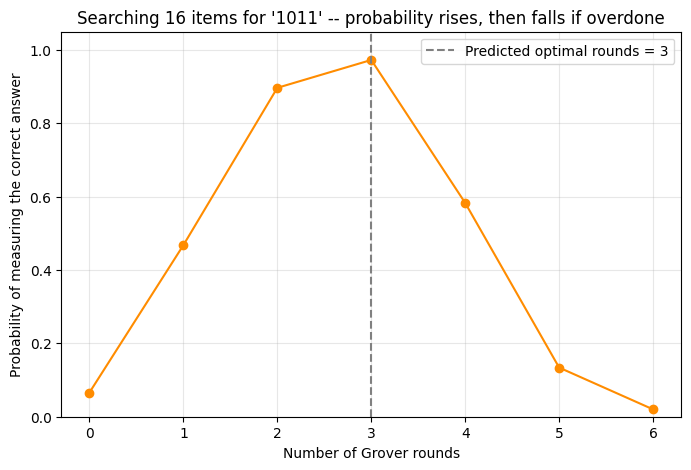

Rounds: 0  |  Success probability: 6.6%
Rounds: 1  |  Success probability: 46.8%
Rounds: 2  |  Success probability: 89.7%
Rounds: 3  |  Success probability: 97.3%  <-- best
Rounds: 4  |  Success probability: 58.3%
Rounds: 5  |  Success probability: 13.4%
Rounds: 6  |  Success probability: 2.0%


In [10]:
n_qubits = 4
target_16 = "1011"
N = 2 ** n_qubits
optimal_rounds = round((math.pi / 4) * math.sqrt(N))

round_counts = list(range(0, 7))
success_probs = [run_grover(n_qubits, target_16, r) for r in round_counts]

plt.figure(figsize=(8, 5))
plt.plot(round_counts, success_probs, marker='o', color='darkorange')
plt.axvline(optimal_rounds, linestyle='--', color='gray', label=f"Predicted optimal rounds = {optimal_rounds}")
plt.xlabel("Number of Grover rounds")
plt.ylabel("Probability of measuring the correct answer")
plt.title(f"Searching {N} items for '{target_16}' -- probability rises, then falls if overdone")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

for r, p in zip(round_counts, success_probs):
    marker = "  <-- best" if r == optimal_rounds else ""
    print(f"Rounds: {r}  |  Success probability: {p:.1%}{marker}")

Notice the shape: probability climbs steeply for the first few rounds, peaks close to the predicted `optimal_rounds` value, and then **falls back down** if you keep going. This is why Grover's algorithm needs you to know roughly how many rounds to run -- too few and you haven't amplified enough, too many and you "overshoot" past the answer.

**Try it yourself:** change `target_16` above to a different 4-character string of 0s and 1s (like `"0110"`) and re-run -- the shape of the curve stays the same, only the specific probabilities shift slightly.

---
## Exercise: Build a Grover Search for 8 Items

Now it's your turn. We'll search a pile of **8 items** (3 qubits this time). Your target is `marked_state = "101"`.

The diffuser is already written for you below (it's the same idea every time, so we won't make you rebuild it). **Your job is to write the oracle** -- the part that recognizes and marks the correct answer.

In [12]:
# Write your code here.
marked_state = "101"   # this is what we're searching for, out of 8 possible answers
n_qubits = 3
N = 2 ** n_qubits

def my_oracle(n_qubits, marked_state):
    qc = QuantumCircuit(n_qubits)

    # TODO Step 1: for every bit in marked_state that is '0', apply an X gate
    #        to that qubit (this temporarily flips 0s to 1s so we can use a
    #        plain multi-controlled Z gate to detect "all 1s")
    # for i, bit in enumerate(reversed(marked_state)):
    #     if bit == '0':
    #         qc.x(i)

    # TODO Step 2: apply a multi-controlled Z on all qubits
    #        (the H - MCX - H trick turns a multi-controlled X into a
    #        multi-controlled Z, which flips the sign instead of the value)
    # qc.h(n_qubits - 1)
    # qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    # qc.h(n_qubits - 1)

    # TODO Step 3: undo Step 1 -- apply X gates again to the same qubits,
    #        to restore everything back to how it was
    # for i, bit in enumerate(reversed(marked_state)):
    #     if bit == '0':
    #         qc.x(i)

    return qc

# This diffuser is provided for you -- no need to change it
def my_diffuser(n_qubits):
    qc = QuantumCircuit(n_qubits)
    qc.h(range(n_qubits))
    qc.x(range(n_qubits))
    qc.h(n_qubits - 1)
    qc.mcx(list(range(n_qubits - 1)), n_qubits - 1)
    qc.h(n_qubits - 1)
    qc.x(range(n_qubits))
    qc.h(range(n_qubits))
    return qc

print("Fill in the TODOs in my_oracle, then run the next cell.")

Fill in the TODOs in my_oracle, then run the next cell.


### Now: figure out how many rounds to run

Recall the formula from Part 1: `rounds ≈ (π/4) × √N`. Fill in the `# TODO` below.

In [ ]:
# Write your code here.
# TODO: compute the number of rounds using the formula (π/4) * sqrt(N), rounded to the nearest whole number
# my_rounds = round((math.pi / 4) * math.sqrt(N))
my_rounds = 0   # replace this once you've filled in the TODO above

print(f"Rounds to run: {my_rounds}")

### Finally: assemble and run your circuit

In [ ]:
qc = QuantumCircuit(n_qubits, n_qubits)
qc.h(range(n_qubits))

for _ in range(my_rounds):
    qc.compose(my_oracle(n_qubits, marked_state), inplace=True)
    qc.compose(my_diffuser(n_qubits), inplace=True)

qc.measure(range(n_qubits), range(n_qubits))

job = simulator.run(qc, shots=1000)
counts = job.result().get_counts()

plt.figure(figsize=(8, 4))
plt.bar(counts.keys(), counts.values(), color=['crimson' if k == marked_state else 'steelblue' for k in counts.keys()])
plt.title(f"Your Grover search for '{marked_state}' out of {N} items")
plt.xlabel("Measured result")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

success_rate = counts.get(marked_state, 0) / 1000
print(f"Success rate: {success_rate:.1%}")
print("If this is well above 1/8 (12.5%, what pure luck would give you), it worked!")

### ✍️ Reflection

- What was your success rate? How does it compare to what pure random guessing would give you (1 in 8, or 12.5%)?
- If the pile had 1,000,000 items instead of 8, roughly how many rounds would Grover's algorithm need? (Use the formula from Part 1.)
- Where do you think a "search through an unsorted pile" problem shows up in real life? (Hint: think about databases, or breaking certain types of passwords.)

*(Your answers here)*